# UPI Fraud Detection — Feature Engineering


In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.preprocess import load_raw, basic_clean, get_feature_names
from features.build_features import (
    engineer_features, fit_anomaly_detector, add_anomaly_scores,
    build_final_preprocessor, FINAL_NUMERIC_COLS, FINAL_CATEGORICAL_COLS, FINAL_FLAG_COLS
)
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_SEED = 42

df = load_raw("../data/raw/upi_transactions.csv")
X, y = basic_clean(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (120000, 11)  Test: (30000, 11)


## 1. Time-Based Features


In [2]:
X_train_fe, thresholds = engineer_features(X_train)
X_test_fe, _ = engineer_features(X_test, thresholds)

X_train_fe[["hour", "hour_sin", "hour_cos", "is_night", "is_weekend"]].head()

,hour,hour_sin,hour_cos,is_night,is_weekend
66762,12,1.224647e-16,-1.000000e+00,0,0
47615,18,-1.000000e+00,-1.836970e-16,0,0
67504,20,-8.660254e-01,5.000000e-01,0,0
21038,14,-5.000000e-01,-8.660254e-01,0,1
92219,7,9.659258e-01,-2.588190e-01,0,0


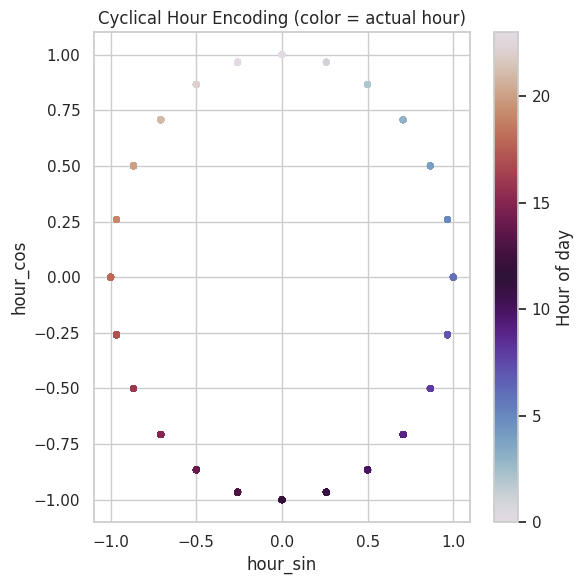

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
sample = X_train_fe.sample(2000, random_state=RANDOM_SEED)
sc = ax.scatter(sample["hour_sin"], sample["hour_cos"], c=sample["hour"], cmap="twilight", s=15)
ax.set_title("Cyclical Hour Encoding (color = actual hour)")
ax.set_xlabel("hour_sin")
ax.set_ylabel("hour_cos")
plt.colorbar(sc, label="Hour of day")
plt.tight_layout()
plt.savefig("../reports/figures/12_cyclical_hour_encoding.png", dpi=150)
plt.show()

## 2. Behavioral Features


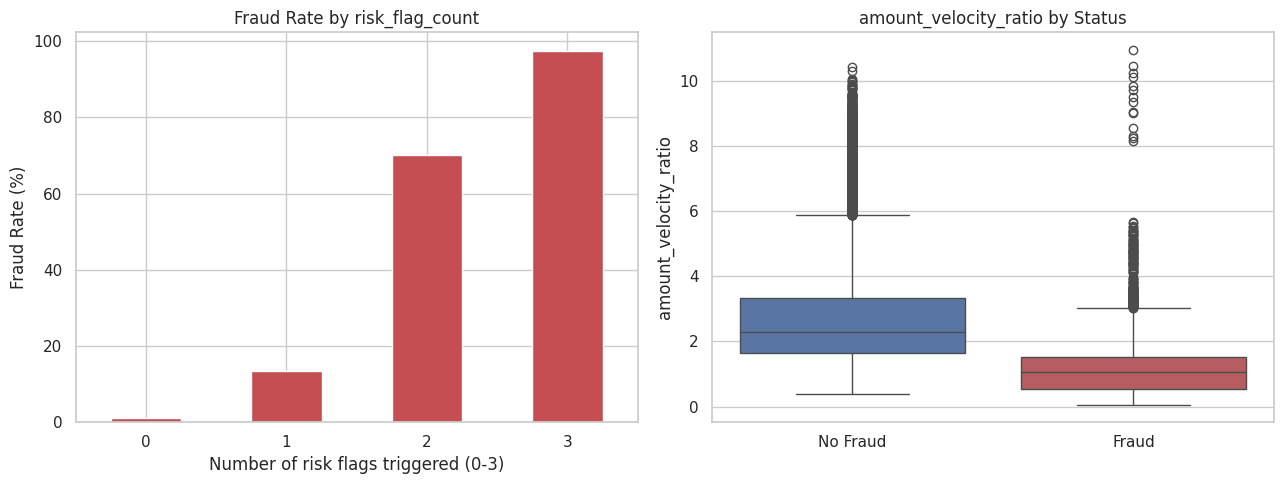

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

risk_fraud_rate = X_train_fe.assign(is_fraud=y_train.values).groupby("risk_flag_count")["is_fraud"].mean() * 100
risk_fraud_rate.plot(kind="bar", color="#C44E52", ax=axes[0])
axes[0].set_title("Fraud Rate by risk_flag_count")
axes[0].set_xlabel("Number of risk flags triggered (0-3)")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].tick_params(axis="x", rotation=0)

sns.boxplot(data=X_train_fe.assign(transaction_status=y_train.map({0: "No Fraud", 1: "Fraud"})),
            x="transaction_status", y="amount_velocity_ratio", hue="transaction_status",
            palette={"No Fraud": "#4C72B0", "Fraud": "#C44E52"}, legend=False, ax=axes[1])
axes[1].set_title("amount_velocity_ratio by Status")
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig("../reports/figures/13_behavioral_features.png", dpi=150)
plt.show()

## 3. Statistical Outlier Flags


In [5]:
print("Thresholds (log-amount scale):", thresholds)

for flag in ["is_large_amount", "is_micro_amount"]:
    rate = X_train_fe.assign(is_fraud=y_train.values).groupby(flag)["is_fraud"].mean() * 100
    print(f"\n{flag} fraud rate:\n{rate}")

Thresholds (log-amount scale): {'large_amount': np.float64(8.755252625531268), 'micro_amount': np.float64(4.467625034402194)}

is_large_amount fraud rate:
is_large_amount
0     4.299123
1    77.233333
Name: is_fraud, dtype: float64

is_micro_amount fraud rate:
is_micro_amount
0     5.115789
1    61.716667
Name: is_fraud, dtype: float64


## 4. Anomaly Detection — Isolation Forest


In [6]:
iso_forest = fit_anomaly_detector(X_train_fe, contamination=0.08)

X_train_fe = add_anomaly_scores(X_train_fe, iso_forest)
X_test_fe = add_anomaly_scores(X_test_fe, iso_forest)

X_train_fe[["anomaly_score", "isolation_forest_flag"]].describe()

,anomaly_score,isolation_forest_flag
count,120000.000000,120000.000000
mean,0.451651,0.080000
std,0.097623,0.271294
min,0.357371,0.000000
25%,0.373263,0.000000
50%,0.412606,0.000000
75%,0.505612,0.000000
max,0.757442,1.000000


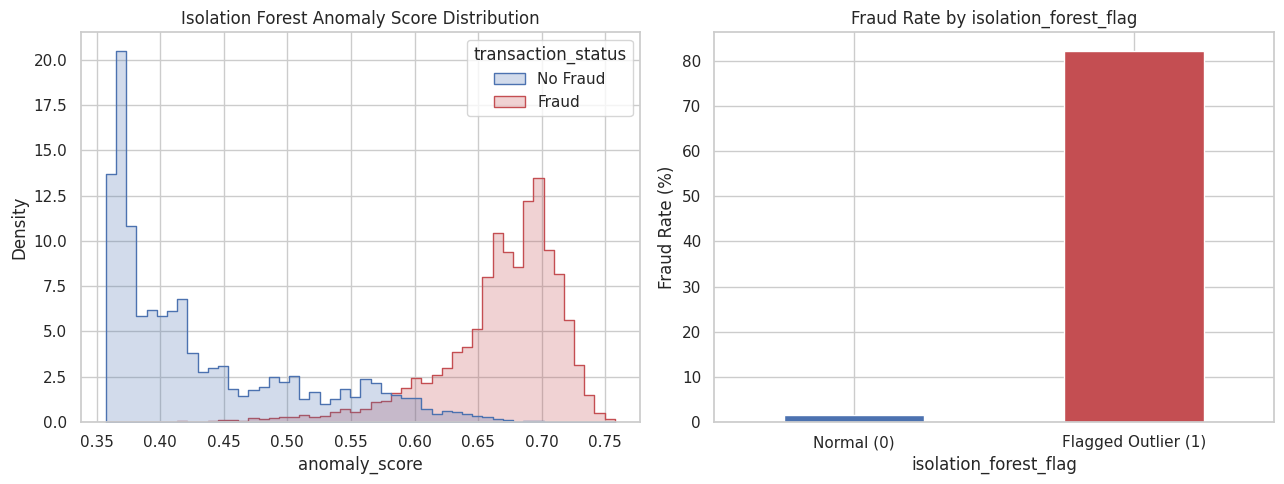

Correlation between anomaly_score and is_fraud: 0.650


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data=X_train_fe.assign(transaction_status=y_train.map({0: "No Fraud", 1: "Fraud"})),
             x="anomaly_score", hue="transaction_status",
             palette={"No Fraud": "#4C72B0", "Fraud": "#C44E52"},
             bins=50, element="step", stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("Isolation Forest Anomaly Score Distribution")

flag_fraud_rate = X_train_fe.assign(is_fraud=y_train.values).groupby("isolation_forest_flag")["is_fraud"].mean() * 100
flag_fraud_rate.plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=axes[1])
axes[1].set_title("Fraud Rate by isolation_forest_flag")
axes[1].set_xticklabels(["Normal (0)", "Flagged Outlier (1)"], rotation=0)
axes[1].set_ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.savefig("../reports/figures/14_anomaly_detection.png", dpi=150)
plt.show()

corr_with_target = np.corrcoef(X_train_fe["anomaly_score"], y_train)[0, 1]
print(f"Correlation between anomaly_score and is_fraud: {corr_with_target:.3f}")

## 5. Correlation Analysis


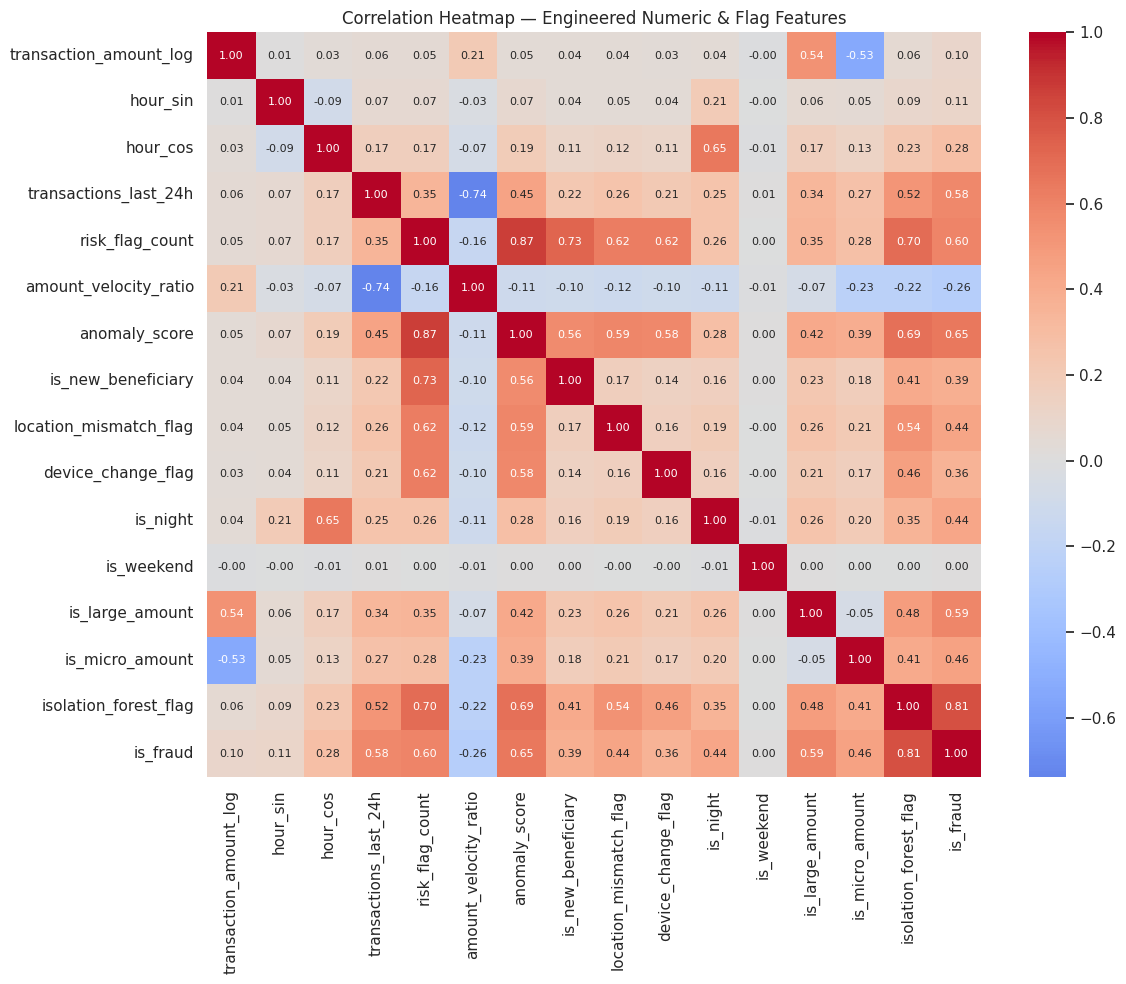

In [8]:
numeric_and_flags = FINAL_NUMERIC_COLS + FINAL_FLAG_COLS
corr_df = X_train_fe[numeric_and_flags].assign(is_fraud=y_train.values)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            annot_kws={"size": 8})
ax.set_title("Correlation Heatmap — Engineered Numeric & Flag Features")
plt.tight_layout()
plt.savefig("../reports/figures/15_final_correlation_heatmap.png", dpi=150)
plt.show()

In [9]:
target_corr = corr_matrix["is_fraud"].drop("is_fraud").sort_values(key=abs, ascending=False)
print("Features ranked by |correlation| with is_fraud:\n")
target_corr

Features ranked by |correlation| with is_fraud:



isolation_forest_flag     0.809596
anomaly_score             0.650380
risk_flag_count           0.595785
is_large_amount           0.587742
transactions_last_24h     0.580659
is_micro_amount           0.456119
location_mismatch_flag    0.442410
is_night                  0.436515
is_new_beneficiary        0.386098
device_change_flag        0.364844
hour_cos                  0.283881
amount_velocity_ratio    -0.261827
hour_sin                  0.110529
transaction_amount_log    0.100830
is_weekend                0.002564
Name: is_fraud, dtype: float64

## 6. Build Final Feature Matrix, Encode, Scale, Balance

In [10]:
preprocessor = build_final_preprocessor()
X_train_proc = preprocessor.fit_transform(X_train_fe)
X_test_proc = preprocessor.transform(X_test_fe)
feature_names = get_feature_names(preprocessor)

print("Final engineered feature count:", len(feature_names))

smote = SMOTE(random_state=RANDOM_SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train_proc, y_train)

print("Balanced train shape:", X_train_bal.shape, " fraud rate:", y_train_bal.mean())
print("Test shape:", X_test_proc.shape, " fraud rate:", y_test.mean().round(4))

Final engineered feature count: 61


Balanced train shape: (220930, 61)  fraud rate: 0.5
Test shape: (30000, 61)  fraud rate: 0.0795


In [11]:
import os, joblib
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models", exist_ok=True)

pd.DataFrame(X_train_bal, columns=feature_names).to_csv("../data/processed/X_train_final.csv", index=False)
pd.Series(y_train_bal, name="is_fraud").to_csv("../data/processed/y_train_final.csv", index=False)
pd.DataFrame(X_test_proc, columns=feature_names).to_csv("../data/processed/X_test_final.csv", index=False)
pd.Series(y_test.values, name="is_fraud").to_csv("../data/processed/y_test_final.csv", index=False)

joblib.dump(preprocessor, "../models/final_preprocessor.pkl")
joblib.dump(iso_forest, "../models/isolation_forest.pkl")
joblib.dump(thresholds, "../models/outlier_thresholds.pkl")

print("Saved final processed datasets and artifacts (preprocessor, isolation forest, thresholds).")

Saved final processed datasets and artifacts (preprocessor, isolation forest, thresholds).
